In [4]:
import pandas as pd

In [24]:
import numpy as np

In [25]:
from scipy import stats

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
users = pd.read_csv("../data/raw/users.csv")
daily_logs = pd.read_csv("../data/raw/daily_logs.csv")
daily_all = pd.read_csv("../data/raw/daily_all.csv")
interventions = pd.read_csv("../data/raw/interventions.csv")
weekly_summaries = pd.read_csv("../data/raw/weekly_summaries.csv")

In [23]:
daily_all

,user_id,date,week_start,workday,profession,work_mode,chronotype,age,sex,height_cm,...,workouts_count,cheat_meals_count,has_intervention,intervention_diet_coaching,intervention_exercise_plan,intervention_meditation,intervention_sick_leave,intervention_therapy,intervention_vacation,intervention_workload_cap
0,1,2024-01-01,2024-01-01,True,operations,onsite,morning,27,female,174,...,10,1,False,False,False,False,False,False,False,False
1,1,2024-01-02,2024-01-01,True,operations,onsite,morning,27,female,174,...,10,1,False,False,False,False,False,False,False,False
2,1,2024-01-03,2024-01-01,True,operations,onsite,morning,27,female,174,...,10,1,False,False,False,False,False,False,False,False
3,1,2024-01-04,2024-01-01,True,operations,onsite,morning,27,female,174,...,10,1,False,False,False,False,False,False,False,False
4,1,2024-01-05,2024-01-01,True,operations,onsite,morning,27,female,174,...,10,1,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730995,1000,2025-12-27,2025-12-22,False,manager,onsite,intermediate,58,female,168,...,5,1,False,False,False,False,False,False,False,False
730996,1000,2025-12-28,2025-12-22,False,manager,onsite,intermediate,58,female,168,...,5,1,False,False,False,False,False,False,False,False
730997,1000,2025-12-29,2025-12-29,True,manager,onsite,intermediate,58,female,168,...,1,1,False,False,False,False,False,False,False,False
730998,1000,2025-12-30,2025-12-29,True,manager,onsite,intermediate,58,female,168,...,1,1,False,False,False,False,False,False,False,False


### Changing data types of date columns to datetime

In [7]:
daily_logs["date"] = pd.to_datetime(daily_logs["date"])
daily_logs["week_start"] = pd.to_datetime(daily_logs["date"])
daily_all["date"] = pd.to_datetime(daily_all["date"])
interventions["start_date"] = pd.to_datetime(interventions["start_date"])
interventions["end_date"] = pd.to_datetime(interventions["end_date"])
weekly_summaries["week_start"] = pd.to_datetime(weekly_summaries["week_start"])

In [12]:
daily_all.isnull().sum()

user_id                       0
date                          0
week_start                    0
workday                       0
profession                    0
work_mode                     0
chronotype                    0
age                           0
sex                           0
height_cm                     0
mental_health_history         0
exercise_habit                0
caffeine_sensitivity          0
baseline_bmi                  0
sleep_hours                   0
sleep_quality                 0
work_hours                    0
meetings_count                0
tasks_completed               0
emails_received               0
commute_minutes               0
exercise_minutes              0
steps_count                   0
caffeine_mg                   0
alcohol_units                 0
screen_time_hours             0
social_interactions           0
outdoor_time_minutes          0
diet_quality                  0
calories_intake               0
stress_level                  0
mood_sco

In [13]:
daily_logs.isnull().sum()

user_id                 0
date                    0
workday                 0
sleep_hours             0
sleep_quality           0
work_hours              0
meetings_count          0
tasks_completed         0
emails_received         0
commute_minutes         0
exercise_minutes        0
steps_count             0
caffeine_mg             0
alcohol_units           0
screen_time_hours       0
social_interactions     0
outdoor_time_minutes    0
diet_quality            0
calories_intake         0
stress_level            0
mood_score              0
energy_level            0
focus_score             0
work_pressure           0
weather_mood_impact     0
weight_kg               0
week_start              0
dtype: int64

In [14]:
interventions.isnull().sum()

user_id         0
start_date      0
end_date        0
type            0
intensity       0
notes         332
dtype: int64

In [15]:
users.isnull().sum()

user_id                  0
age                      0
sex                      0
height_cm                0
profession               0
work_mode                0
chronotype               0
exercise_habit           0
caffeine_sensitivity     0
mental_health_history    0
baseline_bmi             0
dtype: int64

In [16]:
weekly_summaries.isnull().sum()

user_id                   0
week_start                0
job_satisfaction          0
perceived_stress_scale    0
anxiety_score             0
depression_score          0
sleep_debt_hours          0
avg_weight_kg             0
workouts_count            0
cheat_meals_count         0
dtype: int64

In [18]:
print(daily_all.dtypes)

user_id                                int64
date                          datetime64[ns]
week_start                            object
workday                                 bool
profession                            object
work_mode                             object
chronotype                            object
age                                    int64
sex                                   object
height_cm                              int64
mental_health_history                 object
exercise_habit                        object
caffeine_sensitivity                  object
baseline_bmi                         float64
sleep_hours                          float64
sleep_quality                          int64
work_hours                           float64
meetings_count                         int64
tasks_completed                        int64
emails_received                        int64
commute_minutes                        int64
exercise_minutes                       int64
steps_coun

In [19]:
print(daily_logs.dtypes)

user_id                          int64
date                    datetime64[ns]
workday                           bool
sleep_hours                    float64
sleep_quality                    int64
work_hours                     float64
meetings_count                   int64
tasks_completed                  int64
emails_received                  int64
commute_minutes                  int64
exercise_minutes                 int64
steps_count                      int64
caffeine_mg                      int64
alcohol_units                  float64
screen_time_hours              float64
social_interactions              int64
outdoor_time_minutes             int64
diet_quality                     int64
calories_intake                  int64
stress_level                     int64
mood_score                       int64
energy_level                     int64
focus_score                      int64
work_pressure                   object
weather_mood_impact            float64
weight_kg                

In [20]:
print(weekly_summaries.dtypes)

user_id                            int64
week_start                datetime64[ns]
job_satisfaction                   int64
perceived_stress_scale             int64
anxiety_score                      int64
depression_score                   int64
sleep_debt_hours                 float64
avg_weight_kg                    float64
workouts_count                     int64
cheat_meals_count                  int64
dtype: object


In [21]:
print(interventions.dtypes)

user_id                int64
start_date    datetime64[ns]
end_date      datetime64[ns]
type                  object
intensity             object
notes                float64
dtype: object


In [22]:
print(users.dtypes)

user_id                    int64
age                        int64
sex                       object
height_cm                  int64
profession                object
work_mode                 object
chronotype                object
exercise_habit            object
caffeine_sensitivity      object
mental_health_history     object
baseline_bmi             float64
dtype: object


In [ ]:
# checking for outliers in daily logs

d_l_num_cols = daily_logs.select_dtypes(include=['float64', 'int64']).columns

# z-scores column-wise and back into a df
z_scores = pd.DataFrame(np.abs(stats.zscore(daily_logs[d_l_num_cols], nan_policy='omit')),
                        columns=d_l_num_cols)

# outliers (Z > 3)
outliers = z_scores > 3

# number of outliers per column
outlier_summary = outliers.sum().sort_values(ascending=False)

print(outlier_summary.head(10))

outlier_percent = (outliers.sum() / len(daily_logs) * 100).sort_values(ascending=False)
print(outlier_percent.head(10))

meetings_count         6104
social_interactions    4200
alcohol_units          4171
stress_level           2588
calories_intake        1938
steps_count            1937
sleep_hours            1911
screen_time_hours      1882
weight_kg              1711
tasks_completed        1610
dtype: int64
meetings_count         0.835021
social_interactions    0.574555
alcohol_units          0.570588
stress_level           0.354036
calories_intake        0.265116
steps_count            0.264979
sleep_hours            0.261423
screen_time_hours      0.257456
weight_kg              0.234063
tasks_completed        0.220246
dtype: float64


In [35]:
# outliers in daily_all

d_a_num_cols = daily_all.select_dtypes(include=['float64', 'int64']).columns

# z-scores column-wise and back into a df
z_scores = pd.DataFrame(np.abs(stats.zscore(daily_all[d_a_num_cols], nan_policy='omit')),
                        columns=d_a_num_cols)

# outliers (Z > 3)
outliers = z_scores > 3

# number of outliers per column
outlier_summary = outliers.sum().sort_values(ascending=False)

print(outlier_summary.head(10))

outlier_percent = (outliers.sum() / len(daily_all) * 100).sort_values(ascending=False)
print(outlier_percent.head(10))

job_satisfaction       16705
meetings_count          6104
cheat_meals_count       4469
social_interactions     4200
alcohol_units           4171
sleep_debt_hours        3098
stress_level            2588
calories_intake         1938
steps_count             1937
sleep_hours             1911
dtype: int64
job_satisfaction       2.285226
meetings_count         0.835021
cheat_meals_count      0.611354
social_interactions    0.574555
alcohol_units          0.570588
sleep_debt_hours       0.423803
stress_level           0.354036
calories_intake        0.265116
steps_count            0.264979
sleep_hours            0.261423
dtype: float64


In [36]:
w_s_num_cols = weekly_summaries.select_dtypes(include=['float64', 'int64']).columns

# z-scores column-wise and back into a df
z_scores = pd.DataFrame(np.abs(stats.zscore(weekly_summaries[w_s_num_cols], nan_policy='omit')),
                        columns=w_s_num_cols)

# outliers (Z > 3)
outliers = z_scores > 3

# number of outliers per column
outlier_summary = outliers.sum().sort_values(ascending=False)

print(outlier_summary.head(10))

outlier_percent = (outliers.sum() / len(weekly_summaries) * 100).sort_values(ascending=False)
print(outlier_percent.head(10))

job_satisfaction          2411
sleep_debt_hours          1000
cheat_meals_count          639
avg_weight_kg              240
anxiety_score              227
depression_score           137
perceived_stress_scale      84
workouts_count               9
user_id                      0
dtype: int64
job_satisfaction          2.296190
sleep_debt_hours          0.952381
cheat_meals_count         0.608571
avg_weight_kg             0.228571
anxiety_score             0.216190
depression_score          0.130476
perceived_stress_scale    0.080000
workouts_count            0.008571
user_id                   0.000000
dtype: float64


In [38]:
# changing boolean columns from bool type to integer

In [39]:
d_a_bool_cols = [c for c in daily_all.columns if daily_all[c].dtype == 'bool']
daily_all[d_a_bool_cols] = daily_all[d_a_bool_cols].astype(int)

print(f"{len(d_a_bool_cols)} boolean columns to int: {d_a_bool_cols}")

9 boolean columns to int: ['workday', 'has_intervention', 'intervention_diet_coaching', 'intervention_exercise_plan', 'intervention_meditation', 'intervention_sick_leave', 'intervention_therapy', 'intervention_vacation', 'intervention_workload_cap']


In [40]:
d_l_bool_cols = [c for c in daily_logs.columns if daily_logs[c].dtype == 'bool']
daily_logs[d_l_bool_cols] = daily_logs[d_l_bool_cols].astype(int)

print(f"{len(d_l_bool_cols)} boolean columns to int: {d_l_bool_cols}")

1 boolean columns to int: ['workday']


In [41]:
# merging the datasets

In [42]:
merged = daily_all.copy()

# adding intervention flags
for idx, row in interventions.iterrows():
    mask = (
        (merged["user_id"] == row["user_id"]) &
        (merged["date"].between(row["start_date"], row["end_date"]))
    )
    merged.loc[mask, f"intervention_{row['type']}"] = 1

# filling missing intervention flags with 0
intervention_cols = [col for col in merged.columns if col.startswith("intervention_")]
merged[intervention_cols] = merged[intervention_cols].fillna(0).astype(int)

# merging weekly summaries
merged = pd.merge_asof(
    merged.sort_values("date"),
    weekly_summaries.sort_values("week_start"),
    by="user_id",
    left_on="date",
    right_on="week_start",
    direction="backward"
)

In [43]:
# dropping redundant or duplicate week_start columns
merged = merged.drop(columns=["week_start_y"], errors="ignore")
merged.rename(columns={"week_start_x": "week_start"}, inplace=True)

# filling remaining NaNs (after merge) with 0 for numeric columns
numeric_cols = merged.select_dtypes(include=["number"]).columns
merged[numeric_cols] = merged[numeric_cols].fillna(0)


output_path = "../data/processed/merged_health_twin.csv"
merged.to_csv(output_path, index=False)

In [45]:
merged["intervention_start"] = pd.NaT
merged["intervention_end"] = pd.NaT
merged["intervention_type"] = None
merged["intervention_intensity"] = None

for idx, row in interventions.iterrows():
    mask = (
        (merged["user_id"] == row["user_id"]) &
        (merged["date"].between(row["start_date"], row["end_date"]))
    )
    merged.loc[mask, "intervention_start"] = row["start_date"]
    merged.loc[mask, "intervention_end"] = row["end_date"]
    merged.loc[mask, "intervention_type"] = row["type"]
    merged.loc[mask, "intervention_intensity"] = row["intensity"]
    merged.loc[mask, f"intervention_{row['type']}"] = 1



output_path = "../data/processed/merged_1.csv"
merged.to_csv(output_path, index=False)

In [48]:
pd.set_option('display.max_columns', None)

In [50]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731000 entries, 0 to 730999
Data columns (total 65 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   user_id                     731000 non-null  int64         
 1   date                        731000 non-null  datetime64[ns]
 2   week_start                  731000 non-null  object        
 3   workday                     731000 non-null  int64         
 4   profession                  731000 non-null  object        
 5   work_mode                   731000 non-null  object        
 6   chronotype                  731000 non-null  object        
 7   age                         731000 non-null  int64         
 8   sex                         731000 non-null  object        
 9   height_cm                   731000 non-null  int64         
 10  mental_health_history       731000 non-null  object        
 11  exercise_habit              731000 non-

In [51]:
merged.describe()

,user_id,date,workday,age,height_cm,baseline_bmi,sleep_hours,sleep_quality,work_hours,meetings_count,tasks_completed,emails_received,commute_minutes,exercise_minutes,steps_count,caffeine_mg,alcohol_units,screen_time_hours,social_interactions,outdoor_time_minutes,diet_quality,calories_intake,stress_level,mood_score,energy_level,focus_score,weather_mood_impact,weight_kg,job_satisfaction_x,perceived_stress_scale_x,anxiety_score_x,depression_score_x,sleep_debt_hours_x,avg_weight_kg_week,workouts_count_x,cheat_meals_count_x,has_intervention,intervention_diet_coaching,intervention_exercise_plan,intervention_meditation,intervention_sick_leave,intervention_therapy,intervention_vacation,intervention_workload_cap,job_satisfaction_y,perceived_stress_scale_y,anxiety_score_y,depression_score_y,sleep_debt_hours_y,avg_weight_kg,workouts_count_y,cheat_meals_count_y,intervention_start,intervention_end
count,731000.000000,731000,731000.000000,731000.000000,731000.000000,731000.00000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,731000.000000,7081,7081
mean,500.500000,2024-12-31 00:00:00,0.757855,42.847000,169.774000,24.46720,7.208124,6.195785,6.719536,2.574871,6.740937,54.987312,25.744970,28.887067,7222.890431,259.982728,0.565351,6.562296,2.071204,27.018904,5.976483,2255.534862,4.218895,6.166175,5.889287,5.716696,-0.022572,66.757330,6.654233,17.725791,5.095249,11.501921,5.669348,66.757330,6.724937,0.370784,0.009687,0.003094,0.003097,0.000620,0.000495,0.000304,0.000765,0.001445,6.654233,17.725791,5.095249,11.501921,5.669348,66.757330,6.724937,0.370784,2024-12-25 10:35:54.610930432,2025-01-28 09:58:53.907639552
min,1.000000,2024-01-01 00:00:00,0.000000,20.000000,140.000000,18.00000,3.500000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1200.000000,1.000000,1.000000,1.000000,1.000000,-0.500000,38.520000,2.000000,10.000000,3.000000,2.000000,0.000000,38.550000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,10.000000,3.000000,2.000000,0.000000,38.550000,0.000000,0.000000,2024-01-06 00:00:00,2024-01-15 00:00:00
25%,250.750000,2024-07-01 00:00:00,1.000000,31.000000,164.000000,23.00000,6.610000,5.000000,4.070000,1.000000,5.000000,29.000000,14.000000,14.000000,5787.000000,190.000000,0.050000,5.440000,1.000000,16.000000,5.000000,2056.000000,3.000000,5.000000,5.000000,5.000000,-0.100000,61.430000,6.000000,16.000000,4.000000,10.000000,3.800000,61.435714,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,16.000000,4.000000,10.000000,3.800000,61.435714,4.000000,0.000000,2024-07-19 00:00:00,2024-08-21 00:00:00
50%,500.500000,2024-12-31 00:00:00,1.000000,43.000000,170.000000,24.50000,7.200000,6.000000,7.250000,2.000000,7.000000,59.000000,28.000000,28.000000,7222.000000,259.000000,0.480000,6.600000,2.000000,27.000000,6.000000,2254.000000,4.000000,6.000000,6.000000,6.000000,0.100000,66.960000,7.000000,17.000000,5.000000,12.000000,5.500000,66.958571,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,17.000000,5.000000,12.000000,5.500000,66.958571,7.000000,0.000000,2024-12-20 00:00:00,2025-01-25 00:00:00
75%,750.250000,2025-07-02 00:00:00,1.000000,55.000000,175.000000,26.00000,7.800000,7.000000,8.900000,4.000000,9.000000,80.000000,38.000000,42.000000,8658.000000,329.00

In [52]:
pd.reset_option('display.max_columns')

In [54]:
mergedd = pd.read_csv("../data/processed/merged_1.csv", parse_dates=["date", "intervention_start", "intervention_end"])


In [55]:
mergedd.shape

(731000, 65)

In [56]:
mergedd.head()

,user_id,date,week_start,workday,profession,work_mode,chronotype,age,sex,height_cm,...,anxiety_score_y,depression_score_y,sleep_debt_hours_y,avg_weight_kg,workouts_count_y,cheat_meals_count_y,intervention_start,intervention_end,intervention_type,intervention_intensity
0,1,2024-01-01,2024-01-01,1,operations,onsite,morning,27,female,174,...,5,13,0.1,73.132857,10,1,NaT,NaT,NaN,NaN
1,110,2024-01-01,2024-01-01,1,teacher,onsite,morning,40,female,165,...,6,12,5.5,67.138571,2,1,NaT,NaT,NaN,NaN
2,766,2024-01-01,2024-01-01,1,operations,onsite,morning,65,female,171,...,5,9,6.4,61.474286,6,0,NaT,NaT,NaN,NaN
3,767,2024-01-01,2024-01-01,1,wellness_coach,remote,evening,42,female,172,...,4,11,7.1,65.744286,14,2,NaT,NaT,NaN,NaN
4,109,2024-01-01,2024-01-01,1,teacher,onsite,intermediate,35,male,163,...,4,12,7.6,63.647143,3,0,NaT,NaT,NaN,NaN


In [57]:
mergedd.columns

Index(['user_id', 'date', 'week_start', 'workday', 'profession', 'work_mode',
       'chronotype', 'age', 'sex', 'height_cm', 'mental_health_history',
       'exercise_habit', 'caffeine_sensitivity', 'baseline_bmi', 'sleep_hours',
       'sleep_quality', 'work_hours', 'meetings_count', 'tasks_completed',
       'emails_received', 'commute_minutes', 'exercise_minutes', 'steps_count',
       'caffeine_mg', 'alcohol_units', 'screen_time_hours',
       'social_interactions', 'outdoor_time_minutes', 'diet_quality',
       'calories_intake', 'stress_level', 'mood_score', 'energy_level',
       'focus_score', 'work_pressure', 'weather_mood_impact', 'weight_kg',
       'job_satisfaction_x', 'perceived_stress_scale_x', 'anxiety_score_x',
       'depression_score_x', 'sleep_debt_hours_x', 'avg_weight_kg_week',
       'workouts_count_x', 'cheat_meals_count_x', 'has_intervention',
       'intervention_diet_coaching', 'intervention_exercise_plan',
       'intervention_meditation', 'intervention_sic

In [58]:
mergedd.info

<bound method DataFrame.info of         user_id       date  week_start  workday      profession work_mode  \
0             1 2024-01-01  2024-01-01        1      operations    onsite   
1           110 2024-01-01  2024-01-01        1         teacher    onsite   
2           766 2024-01-01  2024-01-01        1      operations    onsite   
3           767 2024-01-01  2024-01-01        1  wellness_coach    remote   
4           109 2024-01-01  2024-01-01        1         teacher    onsite   
...         ...        ...         ...      ...             ...       ...   
730995      659 2025-12-31  2025-12-29        1         manager    onsite   
730996      658 2025-12-31  2025-12-29        1      operations    onsite   
730997      657 2025-12-31  2025-12-29        1         manager    onsite   
730998      670 2025-12-31  2025-12-29        1      operations    onsite   
730999     1000 2025-12-31  2025-12-29        1         manager    onsite   

          chronotype  age     sex  height_c

In [59]:
missing_summary = mergedd.isna().sum().sort_values(ascending=False)
print(missing_summary[missing_summary > 0].head(15))

intervention_start        723919
intervention_type         723919
intervention_end          723919
intervention_intensity    723919
dtype: int64


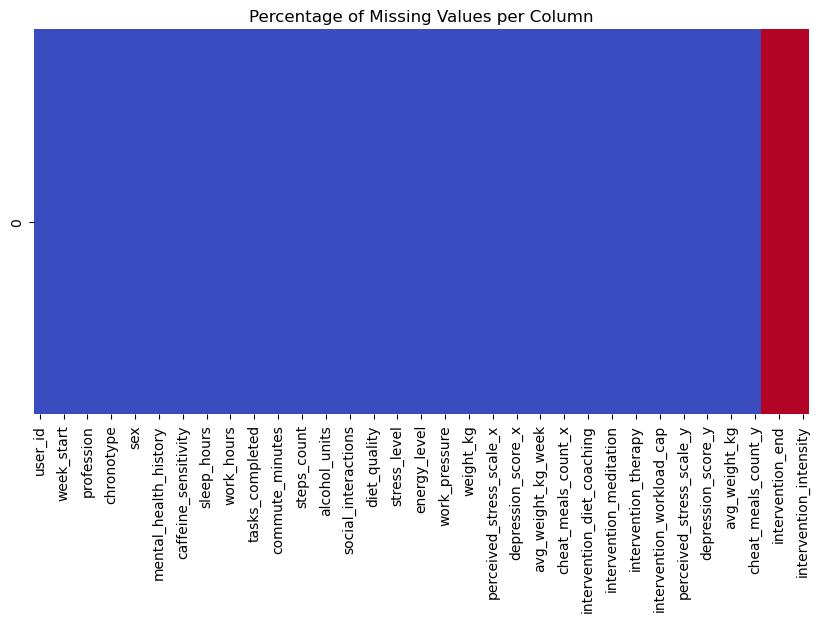

In [ ]:
# visualizing the missing values (cool- less missing values to warm- more missing values)

plt.figure(figsize=(10,5))
sns.heatmap(merged.isna().mean().to_frame().T, cmap="coolwarm", cbar=False)
plt.title("Percentage of Missing Values per Column")
plt.show()

In [62]:
# Checking for duplicate records

In [61]:
dupes = mergedd.duplicated(subset=["user_id", "date"]).sum()
print(f"Duplicate user-day records: {dupes}")

Duplicate user-day records: 0


In [63]:
# Validating intervention information

In [64]:
# how many days each intervention type appears
print(merged["intervention_type"].value_counts(dropna=False))

# How many days were under any intervention
intervention_days = merged["intervention_type"].notna().sum()
print(f"Total intervention days: {intervention_days}")

# How many unique users received interventions
users_with_interventions = merged.loc[merged["intervention_type"].notna(), "user_id"].nunique()
print(f"Users with interventions: {users_with_interventions}")

intervention_type
None             723919
exercise_plan      2264
diet_coaching      2232
workload_cap       1011
vacation            548
meditation          453
sick_leave          351
therapy             222
Name: count, dtype: int64
Total intervention days: 7081
Users with interventions: 250


In [65]:
# Checking if the start date of vintervention is before the end date
mask = (mergedd["date"] < mergedd["intervention_start"]) | (mergedd["date"] > mergedd["intervention_end"])
invalid_rows = mergedd[mask & mergedd["intervention_start"].notna()]

print(f"Invalid intervention date mappings: {len(invalid_rows)}")

Invalid intervention date mappings: 0


In [67]:
# Distribution of core metrics
cols_to_check = ["sleep_hours", "work_hours", "screen_time_hours", "stress_level", "mood_score"]
mergedd[cols_to_check].describe().T

,count,mean,std,min,25%,50%,75%,max
sleep_hours,731000.0,7.208124,0.887098,3.5,6.61,7.20,7.80,10.50
work_hours,731000.0,6.719536,3.257279,0.0,4.07,7.25,8.90,20.58
screen_time_hours,731000.0,6.562296,1.687039,1.0,5.44,6.60,7.72,14.19
stress_level,731000.0,4.218895,1.176108,1.0,3.00,4.00,5.00,9.00
mood_score,731000.0,6.166175,1.464303,1.0,5.00,6.00,7.00,10.00


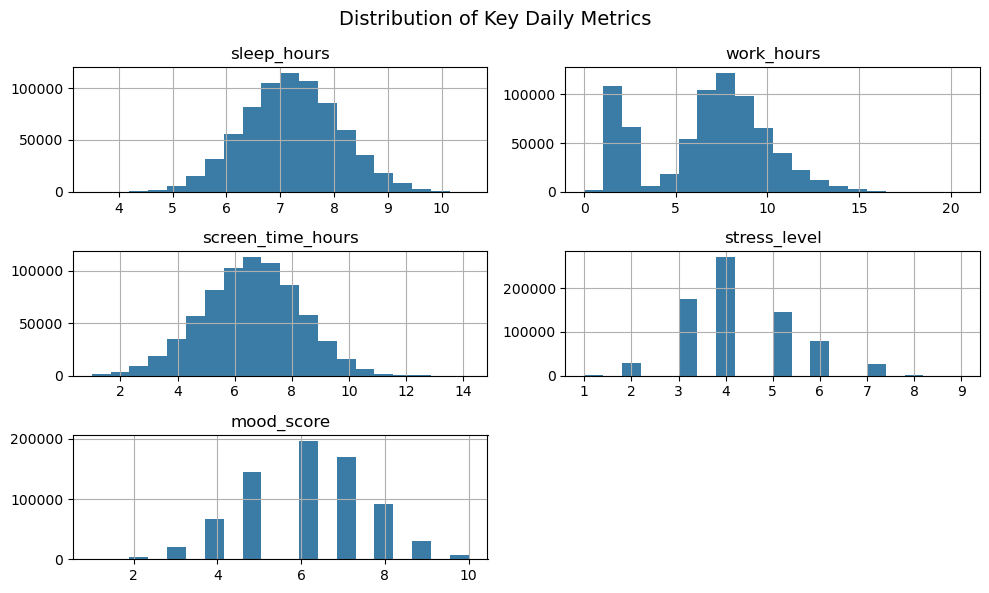

In [68]:
mergedd[cols_to_check].hist(bins=20, figsize=(10, 6), color = "#3A7CA5")
plt.suptitle("Distribution of Key Daily Metrics", fontsize=14)
plt.tight_layout()
plt.show()

In [69]:
# Checking if the weekly summary aligned properly after the merge
mergedd.groupby("user_id")["week_start"].nunique().describe()

count    1000.0
mean      105.0
std         0.0
min       105.0
25%       105.0
50%       105.0
75%       105.0
max       105.0
Name: week_start, dtype: float64

In [70]:
# Our weekly_summaries dataset has data for 105 weeks per user, so this is valid

In [73]:
sample_user = mergedd["user_id"].iloc[0]
mergedd.query("user_id == @sample_user")[["date", "week_start"]]

,date,week_start
0,2024-01-01,2024-01-01
1625,2024-01-02,2024-01-01
2435,2024-01-03,2024-01-01
3546,2024-01-04,2024-01-01
4423,2024-01-05,2024-01-01
...,...,...
726260,2025-12-27,2025-12-22
727212,2025-12-28,2025-12-22
728182,2025-12-29,2025-12-29
729309,2025-12-30,2025-12-29


In [74]:
# Validatoin summary
validation_summary = {
    "rows": len(merged),
    "columns": merged.shape[1],
    "users": merged["user_id"].nunique(),
    "days_with_intervention": int(merged["intervention_type"].notna().sum()),
    "users_with_interventions": int(merged.loc[merged['intervention_type'].notna(), 'user_id'].nunique()),
    "missing_values_total": int(merged.isna().sum().sum()),
    "duplicates": int(merged.duplicated(subset=['user_id', 'date']).sum())
}

import json
with open("../data/processed/validation_summary.json", "w") as f:
    json.dump(validation_summary, f, indent=4)

print("Validation summary saved")

Validation summary saved
